In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# DATA PREP

In [2]:
df = pd.read_csv("dataset/train_post_outlier.csv")

In [3]:
df = df.drop(columns="Unnamed: 0")

In [4]:
df.columns

Index(['runtimeMinutes', 'criticReviewsTotal', 'canHaveEpisodes', 'isAdult',
       'numRegions', 'castNumber', 'companiesNumber', 'averageRating',
       'writerCredits', 'directorsCredits', 'quotesTotal', 'genre_Action',
       'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime',
       'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Romance',
       'genre_Short', 'genre_Unknown', 'sound_Unknown', 'sound_dolby',
       'sound_dolby_atmos', 'sound_dolby_digital', 'sound_dolby_sr',
       'sound_dolby_stereo', 'sound_dts', 'sound_mono', 'sound_sdds',
       'sound_silent', 'sound_stereo', 'continent_Africa',
       'continent_Antarctica', 'continent_Asia', 'continent_Australia',
       'continent_Europe', 'continent_North America', 'continent_Oceania',
       'continent_Other', 'continent_South America', 'release_decade',
       'word_count', 'award_ratio', 'total_multimedia', 'rating_category',
       'sentiment_Negative', 'sentiment_Neutral', 'sentiment_Po

In [5]:
rand = 9
np.random.seed(rand)

X = df.drop(columns=["rating_category", "isAdult"]).copy()
y = df["isAdult"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=rand
)

In [6]:
import catboost as cb

In [7]:
cb_mdl = cb.CatBoostClassifier(learning_rate=0.5, depth=7, random_seed=rand)

# Train Model
fitted_cb_mdl = cb_mdl.fit(X_train, y_train, verbose=False, plot=False)

# Evaluate Model
Y_pred = fitted_cb_mdl.predict(X_train)
print(classification_report(y_train, Y_pred))

Y_pred = fitted_cb_mdl.predict(X_test)
print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90659
           1       1.00      1.00      1.00      1746

    accuracy                           1.00     92405
   macro avg       1.00      1.00      1.00     92405
weighted avg       1.00      1.00      1.00     92405

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22660
           1       0.94      0.89      0.92       442

    accuracy                           1.00     23102
   macro avg       0.97      0.95      0.96     23102
weighted avg       1.00      1.00      1.00     23102



In [10]:
feature_imp = fitted_cb_mdl.get_feature_importance(cb.Pool(X_test, y_test), prettified=True)

In [14]:
feature_imp

,Feature Id,Importances
0,total_multimedia,1.746131e+01
1,release_decade,1.094744e+01
2,castNumber,9.452183e+00
3,runtimeMinutes,7.001059e+00
4,averageRating,6.402417e+00
5,word_count,5.439048e+00
6,companiesNumber,4.692786e+00
7,numRegions,4.498942e+00
8,titleType_movie,3.450303e+00
9,writerCredits,3.354904e+00


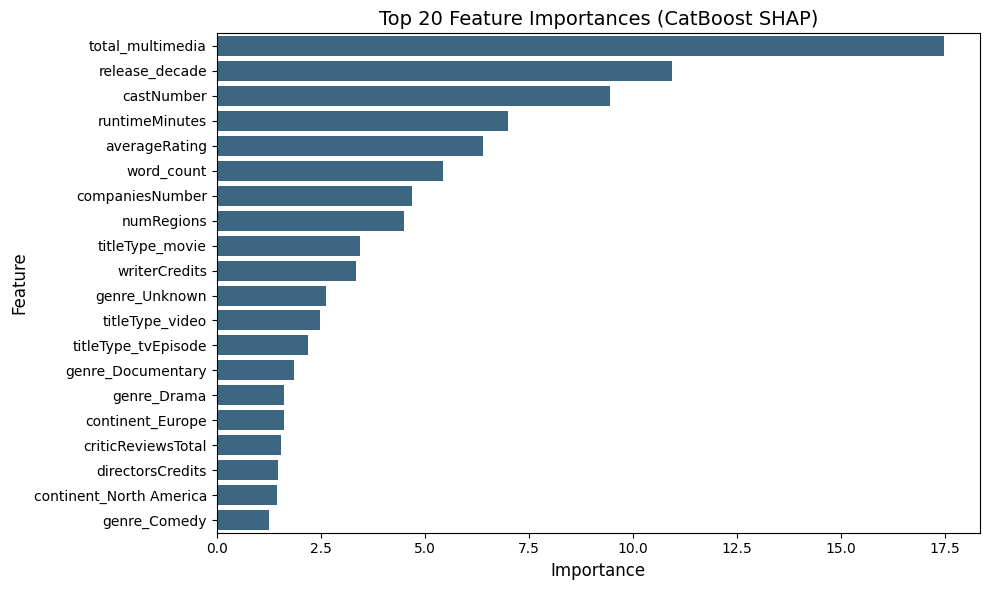

In [24]:
feature_imp_sorted = feature_imp.sort_values("Importances", ascending=False)

top_k = 20
top_features = feature_imp_sorted.head(top_k)

# Barplot orizzontale
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="Importances",
    y="Feature Id",
    palette="viridis",
    hue=y,
    legend=False
)

plt.title("Top 20 Feature Importances (CatBoost SHAP)", fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()


In [8]:
import shap

/var/folders/9v/f8wr4b9x0zdf_z5f4n5y_dr80000gn/T/ipykernel_9485/3349138168.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_test, plot_type="dot", show=False)


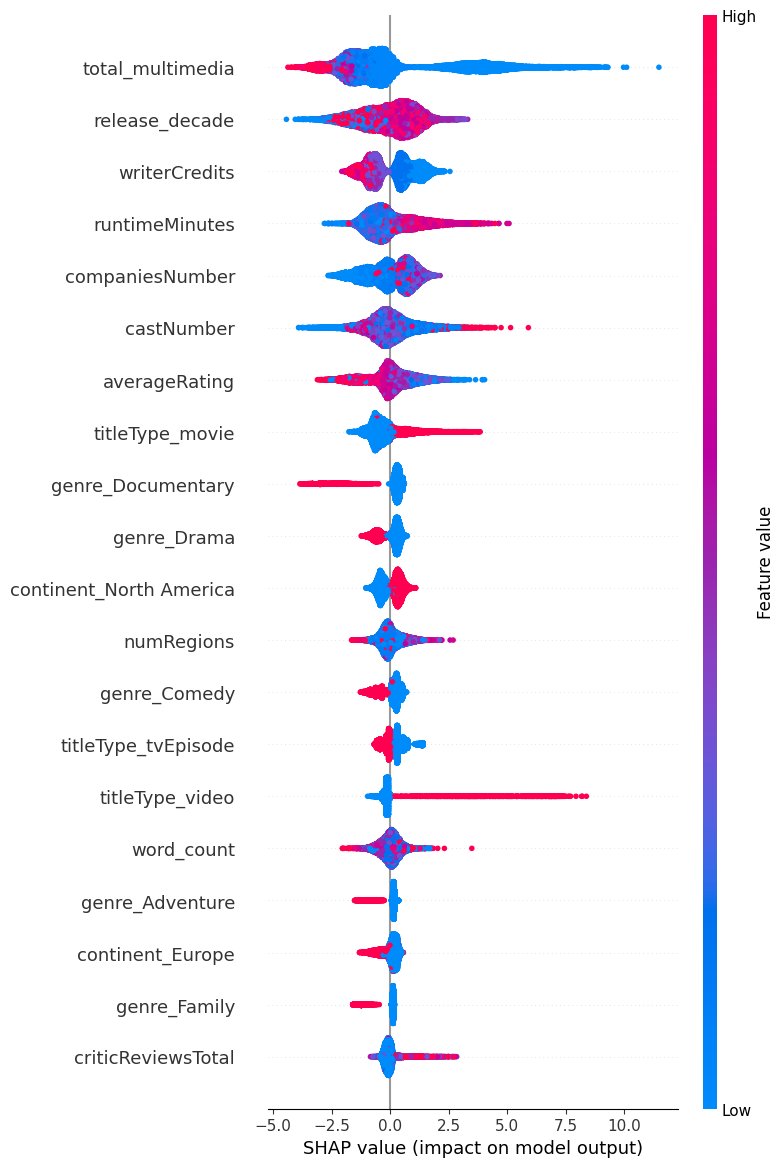

In [26]:
shap_explainer = shap.TreeExplainer(fitted_cb_mdl)
shap_vals = shap_explainer.shap_values(X_test)
shap.summary_plot(shap_vals, X_test, plot_type="dot", show=False)
fig = plt.gcf()
fig.set_size_inches(8, 12)
plt.show()

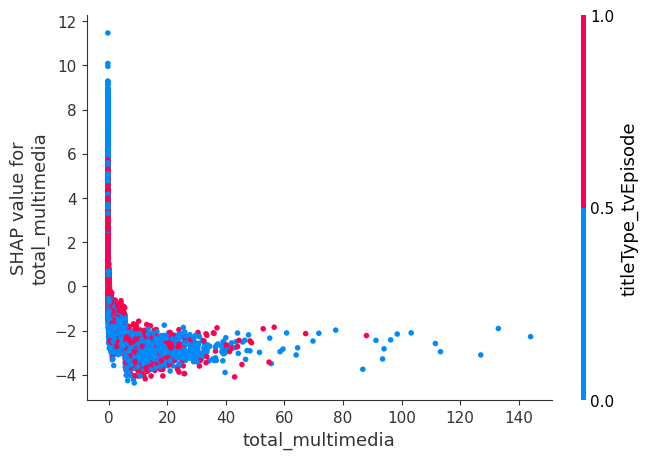

In [27]:
shap.dependence_plot("total_multimedia", shap_vals, X_test)

In [28]:
col_idx_to_name = dict(zip(list(range(0, X_test.shape[1])), X_test.columns))

# Get feature importance for interaction of features and use dictionary to replace indexes with names.
# Output just the top 10 interactions.
fitted_cb_mdl.get_feature_importance(
    cb.Pool(X_test, y_test), type="Interaction", prettified=True
).replace(col_idx_to_name).rename(
    columns={"First Feature Index": "Feature 1", "Second Feature Index": "Feature 2"}
).head(10)

,Feature 1,Feature 2,Interaction
0,runtimeMinutes,castNumber,2.654078
1,castNumber,averageRating,2.192519
2,runtimeMinutes,total_multimedia,2.107280
3,runtimeMinutes,averageRating,2.102550
4,castNumber,total_multimedia,2.000239
5,averageRating,total_multimedia,1.745970
6,release_decade,total_multimedia,1.679319
7,averageRating,word_count,1.340322
8,runtimeMinutes,titleType_video,1.315773
9,runtimeMinutes,word_count,1.194663


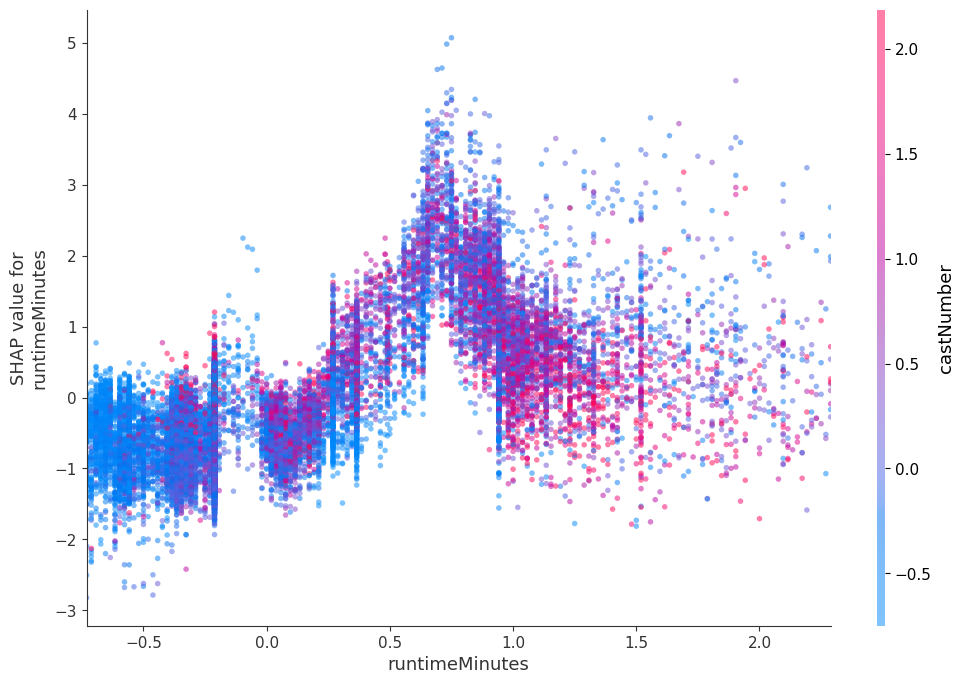

In [29]:
shap.dependence_plot(
    "runtimeMinutes",
    shap_vals,
    X_test,
    interaction_index="castNumber",
    show=False,
    xmin="percentile(1)",
    xmax="percentile(99)",
    alpha=0.5,
)
fig = plt.gcf()
fig.set_size_inches(12, 8)
plt.show()

In [13]:
shap_explainer

## LORE 
from XAILib

In [18]:
%pip install XAI-Library

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.1 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonschema-4.24.0-py3-none-any.whl.metadata (7.8 kB)
  Using cached networkx-3.5-py3-none-any.whl.metadata (6.3 kB)
  Using cached attrs-25.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached jsonschema_specifications-2025.4.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.36.2-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-0.26.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (4.2 kB)
  Using cached MarkupSafe-3.0.2-cp311-cp311-macosx_11_0_arm64.whl.metadata (4.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.2/731.2 kB 4.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 4.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━

In [30]:
from xailib.models.sklearn_classifier_wrapper import sklearn_classifier_wrapper
from xailib.explainers.lore_explainer import LoreTabularExplainer
from xailib.explainers.shap_explainer_tab import ShapXAITabularExplainer

In [31]:
print(fitted_cb_mdl.feature_names_)

['runtimeMinutes', 'criticReviewsTotal', 'canHaveEpisodes', 'numRegions', 'castNumber', 'companiesNumber', 'averageRating', 'writerCredits', 'directorsCredits', 'quotesTotal', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Romance', 'genre_Short', 'genre_Unknown', 'sound_Unknown', 'sound_dolby', 'sound_dolby_atmos', 'sound_dolby_digital', 'sound_dolby_sr', 'sound_dolby_stereo', 'sound_dts', 'sound_mono', 'sound_sdds', 'sound_silent', 'sound_stereo', 'continent_Africa', 'continent_Antarctica', 'continent_Asia', 'continent_Australia', 'continent_Europe', 'continent_North America', 'continent_Oceania', 'continent_Other', 'continent_South America', 'release_decade', 'word_count', 'award_ratio', 'total_multimedia', 'sentiment_Negative', 'sentiment_Neutral', 'sentiment_Positive', 'titleType_movie', 'titleType_short', 'titleType_tvEpisode', 'titleType_tvMiniSeries', 'titleType_tvMovie', 'titleType

In [32]:
bbox = sklearn_classifier_wrapper(fitted_cb_mdl)

In [33]:
print(X_train.columns.tolist())  # double check

['runtimeMinutes', 'criticReviewsTotal', 'canHaveEpisodes', 'numRegions', 'castNumber', 'companiesNumber', 'averageRating', 'writerCredits', 'directorsCredits', 'quotesTotal', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Romance', 'genre_Short', 'genre_Unknown', 'sound_Unknown', 'sound_dolby', 'sound_dolby_atmos', 'sound_dolby_digital', 'sound_dolby_sr', 'sound_dolby_stereo', 'sound_dts', 'sound_mono', 'sound_sdds', 'sound_silent', 'sound_stereo', 'continent_Africa', 'continent_Antarctica', 'continent_Asia', 'continent_Australia', 'continent_Europe', 'continent_North America', 'continent_Oceania', 'continent_Other', 'continent_South America', 'release_decade', 'word_count', 'award_ratio', 'total_multimedia', 'sentiment_Negative', 'sentiment_Neutral', 'sentiment_Positive', 'titleType_movie', 'titleType_short', 'titleType_tvEpisode', 'titleType_tvMiniSeries', 'titleType_tvMovie', 'titleType

In [34]:
inst = X_train.iloc[[147]]
print("Instance ", inst)
print("True class ", y_train.iloc[147])
print("Predicted class ", bbox.predict(inst))


Instance          runtimeMinutes  criticReviewsTotal  canHaveEpisodes  numRegions  \
108878       -0.615385                 1.0            False         0.0   

        castNumber  companiesNumber  averageRating  writerCredits  \
108878       -0.75             -0.5           -1.0      -0.333333   

        directorsCredits  quotesTotal  ...  titleType_movie  titleType_short  \
108878               0.0          0.0  ...            False             True   

        titleType_tvEpisode  titleType_tvMiniSeries  titleType_tvMovie  \
108878                False                   False              False   

        titleType_tvSeries  titleType_tvShort  titleType_tvSpecial  \
108878               False              False                False   

        titleType_video  titleType_videoGame  
108878            False                False  

[1 rows x 58 columns]
True class  0
Predicted class  [0]


In [35]:
feature_names = df.drop(columns=["rating_category", "isAdult"]).columns

In [36]:
feature_names

Index(['runtimeMinutes', 'criticReviewsTotal', 'canHaveEpisodes', 'numRegions',
       'castNumber', 'companiesNumber', 'averageRating', 'writerCredits',
       'directorsCredits', 'quotesTotal', 'genre_Action', 'genre_Adventure',
       'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary',
       'genre_Drama', 'genre_Family', 'genre_Romance', 'genre_Short',
       'genre_Unknown', 'sound_Unknown', 'sound_dolby', 'sound_dolby_atmos',
       'sound_dolby_digital', 'sound_dolby_sr', 'sound_dolby_stereo',
       'sound_dts', 'sound_mono', 'sound_sdds', 'sound_silent', 'sound_stereo',
       'continent_Africa', 'continent_Antarctica', 'continent_Asia',
       'continent_Australia', 'continent_Europe', 'continent_North America',
       'continent_Oceania', 'continent_Other', 'continent_South America',
       'release_decade', 'word_count', 'award_ratio', 'total_multimedia',
       'sentiment_Negative', 'sentiment_Neutral', 'sentiment_Positive',
       'titleType_movie', 't

In [37]:
explainer = ShapXAITabularExplainer(bbox, feature_names)
config = {"explainer": "tree", "X_train": X_train.iloc[0:100].values}
explainer.fit(config)


In [38]:
exp = explainer.explain(inst)

In [39]:
exp.plot_features_importance()

alt.VConcatChart(...)